# Entrega 2 — Análisis Espacial
**Proyecto:** Patrones espaciales y temporales de delitos de alto impacto — CDMX (2019–2024)

Este notebook continúa desde la limpieza ya hecha en el archivo "H2_Procesamiento_de_Datos.ipynb".  
Carga los archivos exportados: `resultados/demografico.gpkg` e `resultados/incidencias.gpkg`

In [30]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import mapclassify
import warnings
warnings.filterwarnings('ignore')

# PySAL
import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

sns.set_theme(style='whitegrid')
print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga de datos

In [31]:
gdf         = gpd.read_file('resultados/demografico.gpkg') 
incidencias = gpd.read_file('resultados/incidencias.gpkg') 

print(f'Colonias cargadas:   {len(gdf)}')
print(f'Delitos (puntos):    {len(incidencias)}')
print(f'CRS colonias:        {gdf.crs}')
print(f'\nColumnas colonias:   {gdf.columns.tolist()}')
print(f'\nTipos de delito únicos: {incidencias["delito"].nunique()}')
incidencias['delito'].value_counts().head(10)

Colonias cargadas:   1814
Delitos (puntos):    189435
CRS colonias:        EPSG:32614

Columnas colonias:   ['alcaldia', 'cve_col', 'colonia', 'n_delitos', 'pob_2010', 'SUP_COL_M2', 'VIV2010', 'DENVIVHa', 'FEMINICIDIO', 'FEMINICIDIO POR ARMA BLANCA', 'FEMINICIDIO POR DISPARO DE ARMA DE FUEGO', 'FEMINICIDIO POR GOLPES', 'HOMICIDIO POR AHORCAMIENTO', 'HOMICIDIO POR ARMA BLANCA', 'HOMICIDIO POR ARMA DE FUEGO', 'HOMICIDIO POR GOLPES', 'HOMICIDIO POR INMERSION', 'HOMICIDIOS INTENCIONALES (OTROS)', 'LESIONES INTENCIONALES POR ARMA DE FUEGO', 'PLAGIO O SECUESTRO', 'ROBO A CASA HABITACION CON VIOLENCIA', 'ROBO A CASA HABITACION Y VEHICULO CON VIOLENCIA', 'ROBO A NEGOCIO (NOMINA) Y VEHICULO CON VIOLENCIA', 'ROBO A NEGOCIO CON VIOLENCIA', 'ROBO A NEGOCIO CON VIOLENCIA POR FARDEROS (TIENDAS DE AUTOSERVICIO)', 'ROBO A NEGOCIO CON VIOLENCIA POR FARDEROS (TIENDAS DE CONVENIENCIA)', 'ROBO A NEGOCIO Y VEHICULO CON VIOLENCIA', 'ROBO A OFICINA PÚBLICA CON VIOLENCIA', 'ROBO A PASAJERO A BORDO DE METRO CO

delito
ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA           53731
ROBO A NEGOCIO CON VIOLENCIA                             23353
ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VIOLENCIA    22140
ROBO A TRANSEUNTE EN VIA PUBLICA SIN VIOLENCIA           11018
ROBO DE MOTOCICLETA SIN VIOLENCIA                         9645
ROBO DE VEHICULO DE SERVICIO PARTICULAR CON VIOLENCIA     9156
ROBO A REPARTIDOR CON VIOLENCIA                           9091
ROBO A PASAJERO A BORDO DE METRO SIN VIOLENCIA            6955
HOMICIDIO POR ARMA DE FUEGO                               5252
VIOLACION                                                 4301
Name: count, dtype: int64

## 2 Unidad de análisis: colonia

El analisis de realiza a nivel de colonia, unidad territorial simil a un barrio, villa, vecindario. Hay tres justificaciones:

1. Granularidad adecuada: las 1,814 colonias de la CDMX permiten detectar variacion espacial intra alcaldia, que se perderia si se agregara a nivel de alcaldia, ademas escala demasiado para identficar micropatrones como lo hace Chainey.

2. Compatibilidad de fuentes: tanto los datos de incidencia como los demograficos estan disponibles con identificador de colonia lo que permite una union directa sin necesidad de interpolacion espacial.

3. Coherencia con la literatura: Vilalta & Fondevila (2022) trabajan a nivel de cuadrante policial en la CDMX, unidad que escala comparable a la colonia. Usar colonias permite replicar su enfoque.

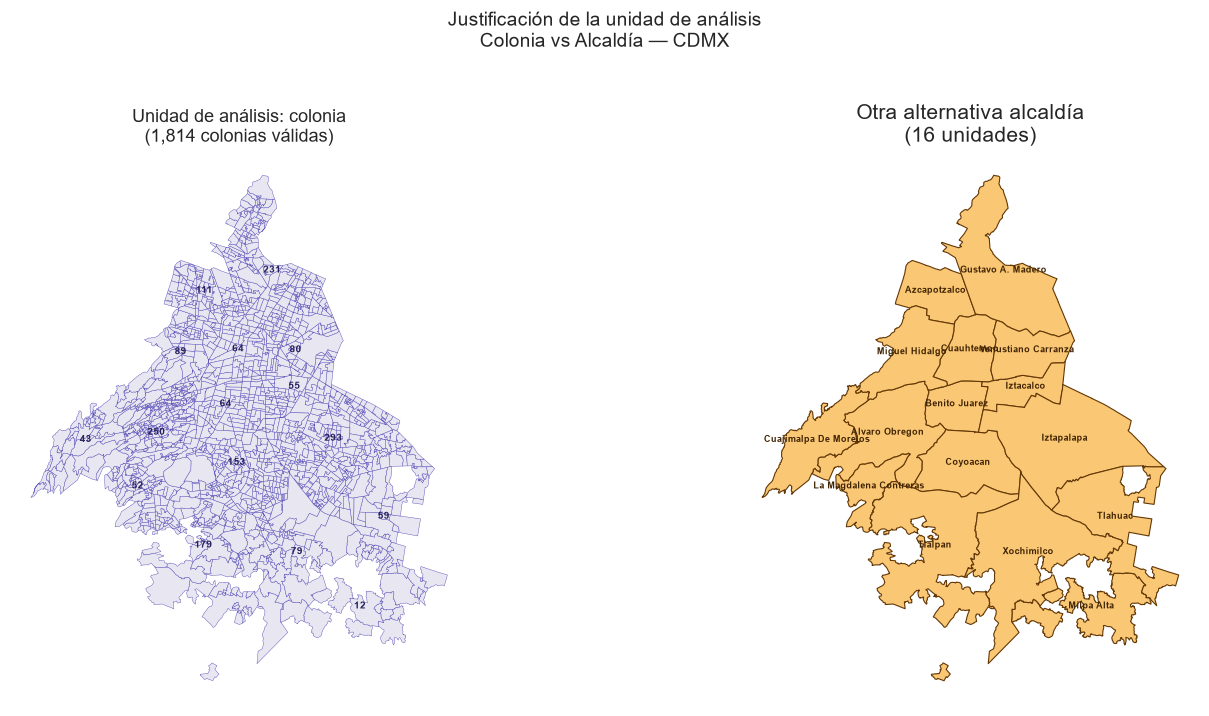

Colonias: 1,814 unidades
Alcaldías: 16 unidades
Ratio: 113x más resolución con colonias


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Mapa izquierdo: colonias ---
gdf.plot(
    ax=axes[0],
    facecolor='#E8E6F0',
    edgecolor='#534AB7',
    linewidth=0.3
)
axes[0].set_title(
    f'Unidad de análisis: colonia\n({len(gdf):,} colonias válidas)',
    fontsize=13
)
axes[0].set_axis_off()

centroides = gdf.dissolve(by='alcaldia').centroid
n_por_alcaldia = gdf.groupby('alcaldia').size()
for alcaldia, punto in centroides.items():
    n = n_por_alcaldia.get(alcaldia, 0)
    axes[0].annotate(
        f'{n}',
        xy=(punto.x, punto.y),
        fontsize=7,
        ha='center',
        color='#26215C',
        fontweight='bold'
    )

# --- Mapa derecho: alcaldías (para comparar escala) ---
alcaldias = gdf.dissolve(by='alcaldia').reset_index()
alcaldias.plot(
    ax=axes[1],
    facecolor='#FAC775',
    edgecolor='#633806',
    linewidth=0.8
)
axes[1].set_title(
    f'Otra alternativa alcaldía\n({len(alcaldias)} unidades)',
    fontsize=15
)
axes[1].set_axis_off()

# Nombres de alcaldías
for _, row in alcaldias.iterrows():
    punto = row.geometry.centroid
    axes[1].annotate(
        row['alcaldia'].title(),
        xy=(punto.x, punto.y),
        fontsize=6.5,
        ha='center',
        color='#412402',
        fontweight='bold'
    )

plt.suptitle(
    'Justificación de la unidad de análisis\nColonia vs Alcaldía — CDMX',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('resultados/00_unidad_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Colonias: {len(gdf):,} unidades')
print(f'Alcaldías: {len(alcaldias)} unidades')
print(f'Ratio: {len(gdf)/len(alcaldias):.0f}x más resolución con colonias')

## 3. Mapas coropléticos — total y por tipo

Se visualiza la distribucion espacial de la tasa de delitos por 100k habitantes usando clasificaiocn Fisher-Jenks con k=5. Se generan dos mapas: uno con la tasa total y otro comparando los 4 tipos de delito mas fracuentes, para responder si distintos delitos ocuuren en colonias distintas.

In [33]:
np.random.seed(12345)  # Semilla 
jc5 = mapclassify.JenksCaspall(gdf["tasa_100k"], k=5)
jc5

JenksCaspall

       Interval          Count
------------------------------
[     0.00,   1069.79] |   526
(  1069.79,   2051.28] |   630
(  2051.28,   3698.00] |   434
(  3698.00,   8843.54] |   183
(  8843.54, 512500.00] |    41

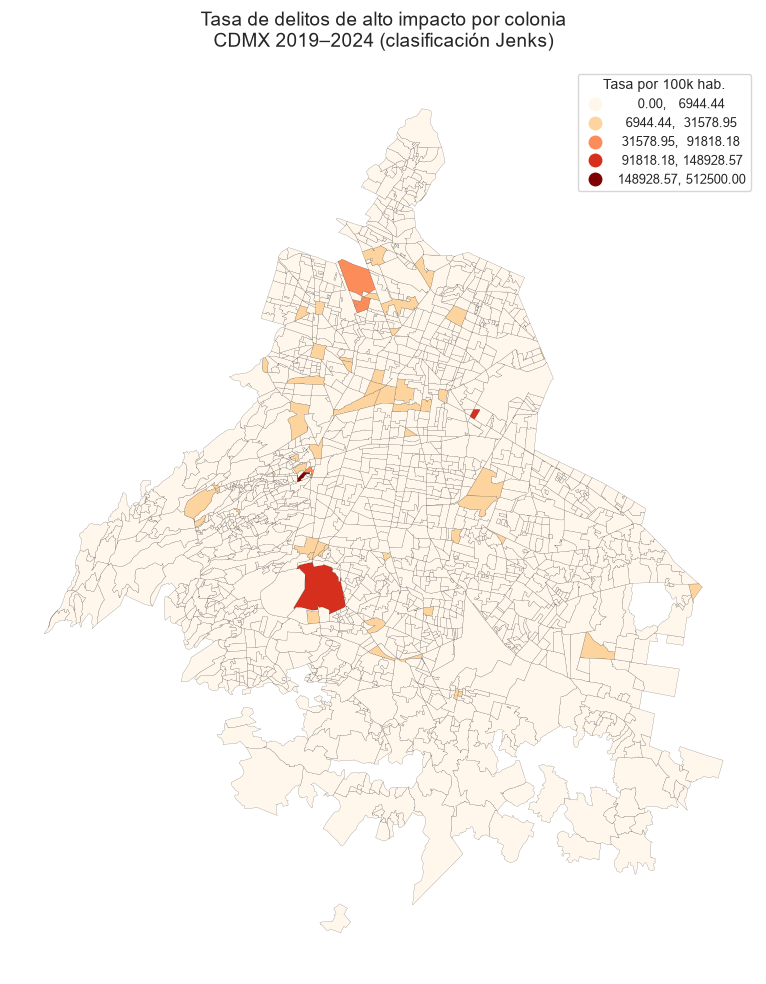

In [34]:
# ── Mapa 1: Tasa total por colonia ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column='tasa_100k',
    scheme='FisherJenks',
    k=5,
    cmap='OrRd',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.1,
    legend_kwds={
        'title': 'Tasa por 100k hab.',
        'fontsize': 9,
        'title_fontsize': 10
    }
)

ax.set_title(
    'Tasa de delitos de alto impacto por colonia\nCDMX 2019–2024 (clasificación Jenks)',
    fontsize=14, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('resultados/01_mapa_tasa_total.png', dpi=150, bbox_inches='tight')
plt.show()

Se puede apreciar que hay varias zonas bien claras ya que sus tasas son muy pequeñas, en cambio hay una colonia que es un outlier. 

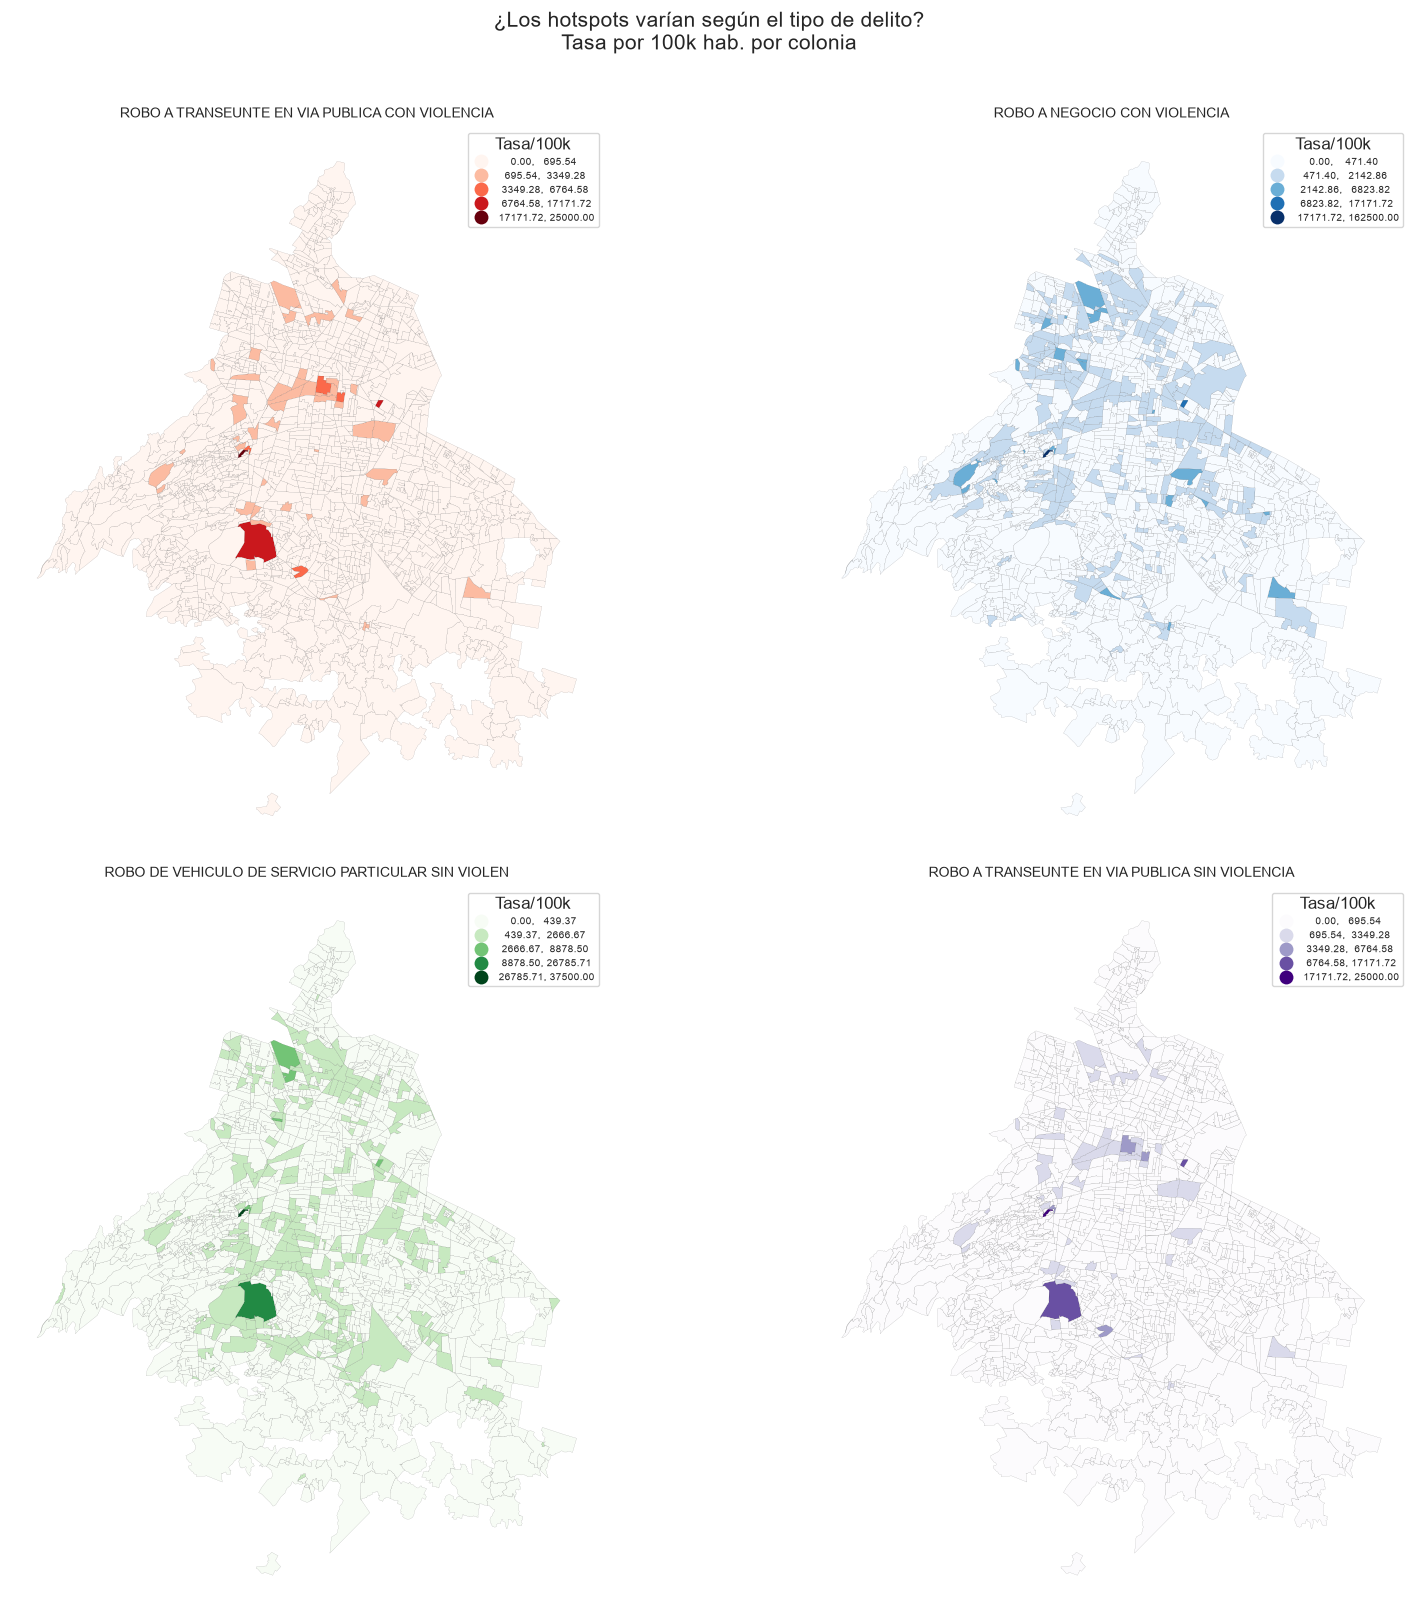

In [35]:
# ── Mapa 2: Comparación entre tipos de delito ─────────────────────────────────
# Toma los 4 tipos más frecuentes
top4 = incidencias['delito'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

cmaps = ['Reds', 'Blues', 'Greens', 'Purples']

for i, tipo in enumerate(top4):
    col_tasa = f'tasa_{tipo[:20]}'
    
    # Verificar que la columna existe
    if col_tasa not in gdf.columns:
        gdf[col_tasa] = np.where(
            gdf['pob_2010'] > 0,
            gdf[tipo] / gdf['pob_2010'] * 100_000,
            np.nan
        )
    
    gdf.plot(
        column=col_tasa,
        scheme='FisherJenks',
        k=5,
        cmap=cmaps[i],
        legend=True,
        ax=axes[i],
        edgecolor='black',
        linewidth=0.05,
        legend_kwds={'title': 'Tasa/100k', 'fontsize': 7}
    )
    axes[i].set_title(f'{tipo[:50]}', fontsize=10, pad=8)
    axes[i].set_axis_off()

plt.suptitle(
    '¿Los hotspots varían según el tipo de delito?\nTasa por 100k hab. por colonia',
    fontsize=15, y=1.01
)
plt.tight_layout()
plt.savefig('resultados/02_mapas_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

Al separar por tipo de delito,  los cuatro mapas muestran zonas distintas entre sí, aunque con algunas coincidencias, com por ejemplo en el centro hay una gran colonia que en tres de los cuatro mapas tiene un alto valor.  

## 4. Distribución temporal por tipo de delito

Se analiza cómo varía la frecuencia de delitos segun la hora del dia, y si ese patrón difere entre tipos de delitos. Se normaliza por tipo para comparar patrones. Nos ayuda a responder la subpregunta 3.

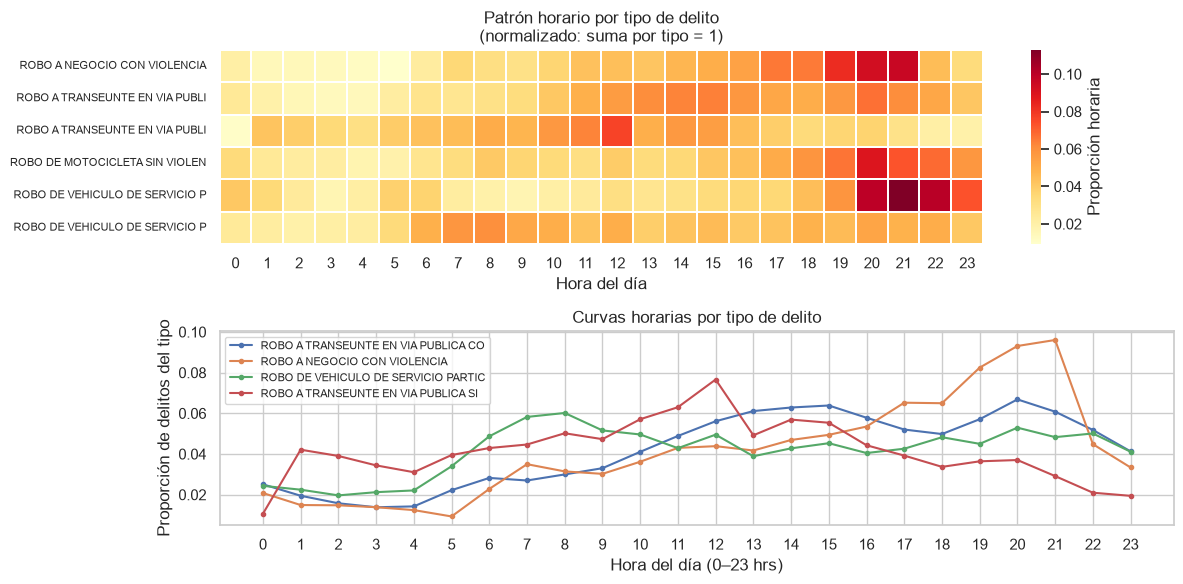

In [36]:
# Heatmap hora × tipo de delito
top6 = incidencias['delito'].value_counts().head(6).index.tolist()
incidencias_top = incidencias[incidencias['delito'].isin(top6)].copy()

pivot_hora = (
    incidencias_top
    .groupby(['hora_hecho', 'delito'])
    .size()
    .reset_index(name='n')
    .pivot_table(index='hora_hecho', columns='delito', values='n', fill_value=0)
)

# Normalizar por columna para comparar patrones (no volúmenes)
pivot_hora_norm = pivot_hora.div(pivot_hora.sum(axis=0), axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Heatmap normalizado
sns.heatmap(
    pivot_hora_norm.T,
    cmap='YlOrRd',
    ax=axes[0],
    cbar_kws={'label': 'Proporción horaria'},
    linewidths=0.3
)
axes[0].set_title('Patrón horario por tipo de delito\n(normalizado: suma por tipo = 1)', fontsize=12)
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('')
axes[0].set_yticklabels([t[:30] for t in pivot_hora_norm.columns], fontsize=8)

# Líneas por tipo
for tipo in top6[:4]:
    if tipo in pivot_hora_norm.columns:
        axes[1].plot(pivot_hora_norm.index, pivot_hora_norm[tipo],
                     marker='o', markersize=3, linewidth=1.5, label=tipo[:35])
axes[1].set_title('Curvas horarias por tipo de delito', fontsize=12)
axes[1].set_xlabel('Hora del día (0–23 hrs)')
axes[1].set_ylabel('Proporción de delitos del tipo')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('resultados/03_distribucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Autocorrelación espacial global — Moran's I

Verifica si existe clustering espacial en la tasa de delitos.

In [37]:
# Matriz de pesos espaciales (contigüidad Queen)
w = Queen.from_dataframe(gdf, silence_warnings=True)
w.transform = 'r'

print(f'Colonias en la matriz: {w.n}')
print(f'Vecinos promedio:      {w.mean_neighbors:.1f}')
print(f'Islas (sin vecinos):   {len(w.islands)}')

Colonias en la matriz: 1814
Vecinos promedio:      5.8
Islas (sin vecinos):   1


  Moran's I  = 0.1479
  p-valor    = 0.0010
  z-score    = 10.3798


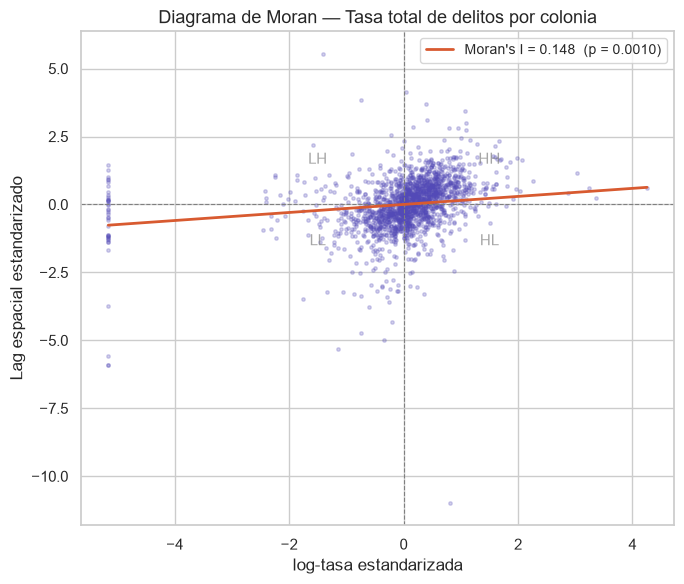

In [38]:
# Moran's I sobre log-tasa total
y_arr = gdf['log_tasa'].values
moran_global = Moran(y_arr, w)

print('=' * 45)
print(f"  Moran's I  = {moran_global.I:.4f}")
print(f"  p-valor    = {moran_global.p_sim:.4f}")
print(f"  z-score    = {moran_global.z_sim:.4f}")
print('=' * 45)

# Diagrama de Moran
lag_y = libpysal.weights.lag_spatial(w, y_arr)
y_std   = (y_arr - y_arr.mean()) / y_arr.std()
lag_std = (lag_y - lag_y.mean()) / lag_y.std()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_std, lag_std, alpha=0.25, s=6, color='#534AB7')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.plot(sorted(y_std),
        [moran_global.I * xi for xi in sorted(y_std)],
        color='#D85A30', linewidth=2,
        label=f"Moran's I = {moran_global.I:.3f}  (p = {moran_global.p_sim:.4f})")

for txt, xy in [('HH',(1.5,1.5)),('LL',(-1.5,-1.5)),('HL',(1.5,-1.5)),('LH',(-1.5,1.5))]:
    ax.text(*xy, txt, fontsize=11, color='gray', ha='center', alpha=0.7)

ax.set_xlabel('log-tasa estandarizada')
ax.set_ylabel('Lag espacial estandarizado')
ax.set_title("Diagrama de Moran — Tasa total de delitos por colonia", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('resultados/04_moran_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Resultado: I ≈ 0.148 (p = 0,001) → autocorrelación espacial positiva y significativa. Esto significa que las colonias con altas tasa de delitos tienden a estar rodeadas de otras colonias con alta tasa. El patron no es aleatorio.

In [45]:
# Moran's I también para los top tipos de delito
print('Moran\'s I por tipo de delito:')
print(f'{"Tipo":<45}  {"I":>7}  {"p":>7}')
print('-' * 62)

resultados_moran = []
for tipo in top4:
    if tipo in gdf.columns:
        col_tasa = f'tasa_{tipo[:20]}'
        if col_tasa not in gdf.columns:
            gdf[col_tasa] = np.where(
                gdf['pob_2010'] > 0,
                gdf[tipo] / gdf['pob_2010'] * 100_000, np.nan
            )
        y_tipo = np.log1p(gdf[col_tasa].fillna(0).values)
        m = Moran(y_tipo, w)
        sig = '✓' if m.p_sim < 0.05 else ' '
        print(f'{sig} {tipo[:43]:<43}  {m.I:>7.4f}  {m.p_sim:>7.4f}')
        resultados_moran.append({'tipo': tipo, 'I': m.I, 'p': m.p_sim})


Moran's I por tipo de delito:
Tipo                                                 I        p
--------------------------------------------------------------
✓ ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLEN   0.2661   0.0010
✓ ROBO A NEGOCIO CON VIOLENCIA                  0.1878   0.0010
✓ ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN   0.1557   0.0010
✓ ROBO A TRANSEUNTE EN VIA PUBLICA SIN VIOLEN   0.2661   0.0010


Los cuatro tipos muestran autocorrelacion significativa. El robo a transeunte con y sin violencia tiene el I mas alto, casi el doble del I global, lo que indica una concentracion espacial mucho mas fuerte que el promedio.

## 6. LISA — Mapa de hotspots y coldspots

El analisis LISA mide como una variable se agrupa geograficamente, comparandola con su entorno. Nos ayuda para la subpregunta 2 sobre la existencia de hotpots.

lisa_cat
No significativo    1411
HH (hotspot)         320
LL (coldspot)         35
LH                    33
HL                    15
Name: count, dtype: int64


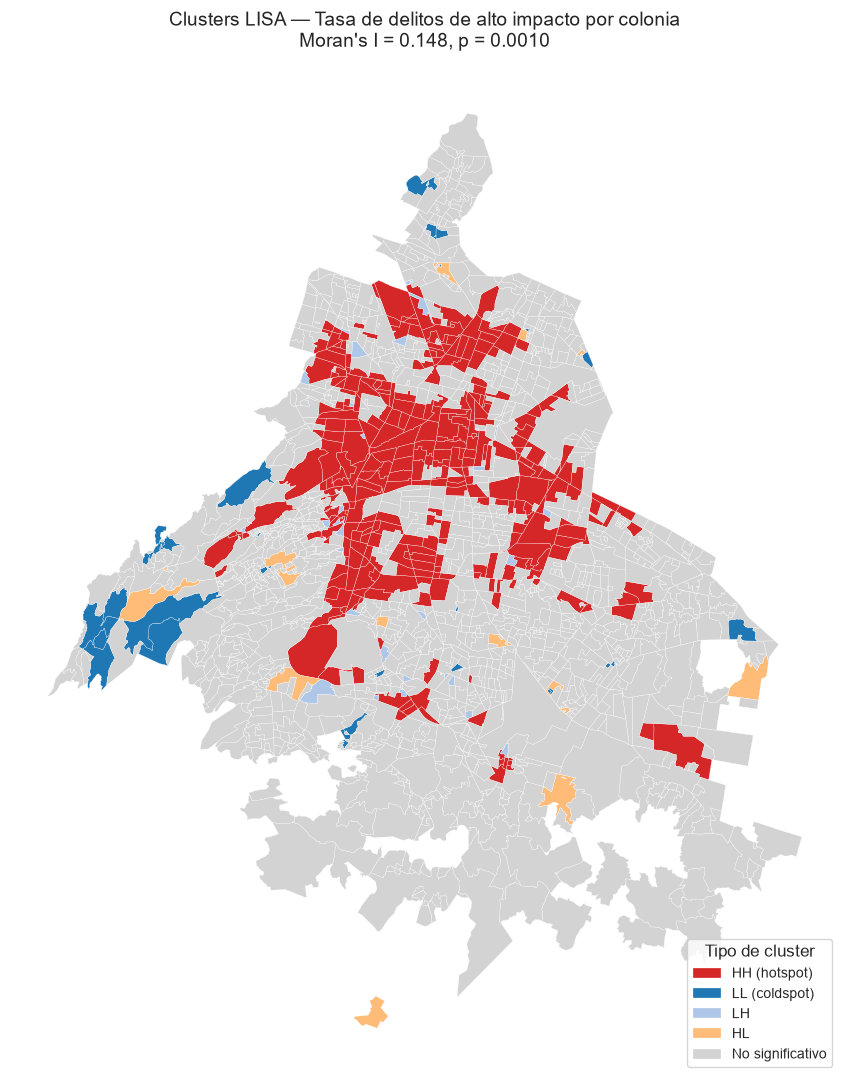

In [46]:
# LISA sobre tasa total
moran_loc = Moran_Local(y_arr, w, seed=42)

sig = moran_loc.p_sim < 0.05
q   = moran_loc.q

gdf['lisa_cat'] = 'No significativo'
gdf.loc[sig & (q == 1), 'lisa_cat'] = 'HH (hotspot)'
gdf.loc[sig & (q == 3), 'lisa_cat'] = 'LL (coldspot)'
gdf.loc[sig & (q == 2), 'lisa_cat'] = 'LH'
gdf.loc[sig & (q == 4), 'lisa_cat'] = 'HL'

print(gdf['lisa_cat'].value_counts())

# Mapa LISA
color_map = {
    'HH (hotspot)':    '#D62728',
    'LL (coldspot)':   '#1F77B4',
    'LH':              '#AEC7E8',
    'HL':              '#FFBB78',
    'No significativo':'#D3D3D3',
}

fig, ax = plt.subplots(figsize=(11, 11))

for cat, color in color_map.items():
    subset = gdf[gdf['lisa_cat'] == cat]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.2, label=cat)

ax.set_title(
    f'Clusters LISA — Tasa de delitos de alto impacto por colonia\n'
    f"Moran's I = {moran_global.I:.3f}, p = {moran_global.p_sim:.4f}",
    fontsize=14, pad=15
)
ax.legend(title='Tipo de cluster', loc='lower right', fontsize=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('resultados/05_mapa_lisa.png', dpi=150, bbox_inches='tight')
plt.show()

Los hotspots se concentran en el centro norte de la ciudad de mexico, y en la periferia se puede observar un par de coldspots.

## 7. Primera implementación GWR

Se implementa una regresion geograficamente ponderada (GWR) siguiendo a **Vilalta & Fondevila (2022)**, con la log-tasa de delitos como variable dependiente y el logaritmo de la densidad poblacional como variable independiente. Los puntos usados son los centroides de las colonias no los puntos de delutos individuales.

In [47]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# Proyectar a UTM zona 14N (métrico, necesario para GWR)
gdf_proj = gdf.to_crs('EPSG:32614')

# Centroides
coords = np.column_stack([
    gdf_proj.geometry.centroid.x,
    gdf_proj.geometry.centroid.y
])

# Variable dependiente e independiente
y = gdf[['log_tasa']].values.astype(float)
X = gdf[['log_dens_pob']].values.astype(float)

print(f'n = {len(y)} colonias')

selector = Sel_BW(coords, y, X, kernel='gaussian', fixed=False, constant=True)
bw = selector.search(criterion='AICc', search_method='golden_section')
print(f'Bandwidth óptimo: {bw:.0f} vecinos ({bw/len(y)*100:.1f}% de colonias)')

n = 1814 colonias
Bandwidth óptimo: 45 vecinos (2.5% de colonias)


In [48]:
# Estimar GWR
gwr_model   = GWR(coords, y, X, bw, kernel='gaussian', fixed=False, constant=True)
gwr_results = gwr_model.fit()

# Extraer coeficientes al GeoDataFrame
gdf['gwr_intercepto']  = gwr_results.params[:, 0]
gdf['gwr_coef_densidad'] = gwr_results.params[:, 1]
gdf['gwr_r2_local']    = gwr_results.localR2
gdf['gwr_t_densidad']  = gwr_results.tvalues[:, 1]
gdf['gwr_sig']         = np.abs(gdf['gwr_t_densidad']) > 1.96

print(f"GWR R² = {gwr_results.R2:.4f}")
print(f"AICc   = {gwr_results.aicc:.2f}")
print(f"\nCoeficiente local de densidad pob.:")
print(f"  Mínimo:  {gdf['gwr_coef_densidad'].min():.4f}")
print(f"  Mediana: {gdf['gwr_coef_densidad'].median():.4f}")
print(f"  Máximo:  {gdf['gwr_coef_densidad'].max():.4f}")
print(f"  % colonias con efecto sig.: {gdf['gwr_sig'].mean()*100:.1f}%")

GWR R² = 0.2995
AICc   = 5802.43

Coeficiente local de densidad pob.:
  Mínimo:  -1.3094
  Mediana: -0.8606
  Máximo:  0.1002
  % colonias con efecto sig.: 94.7%


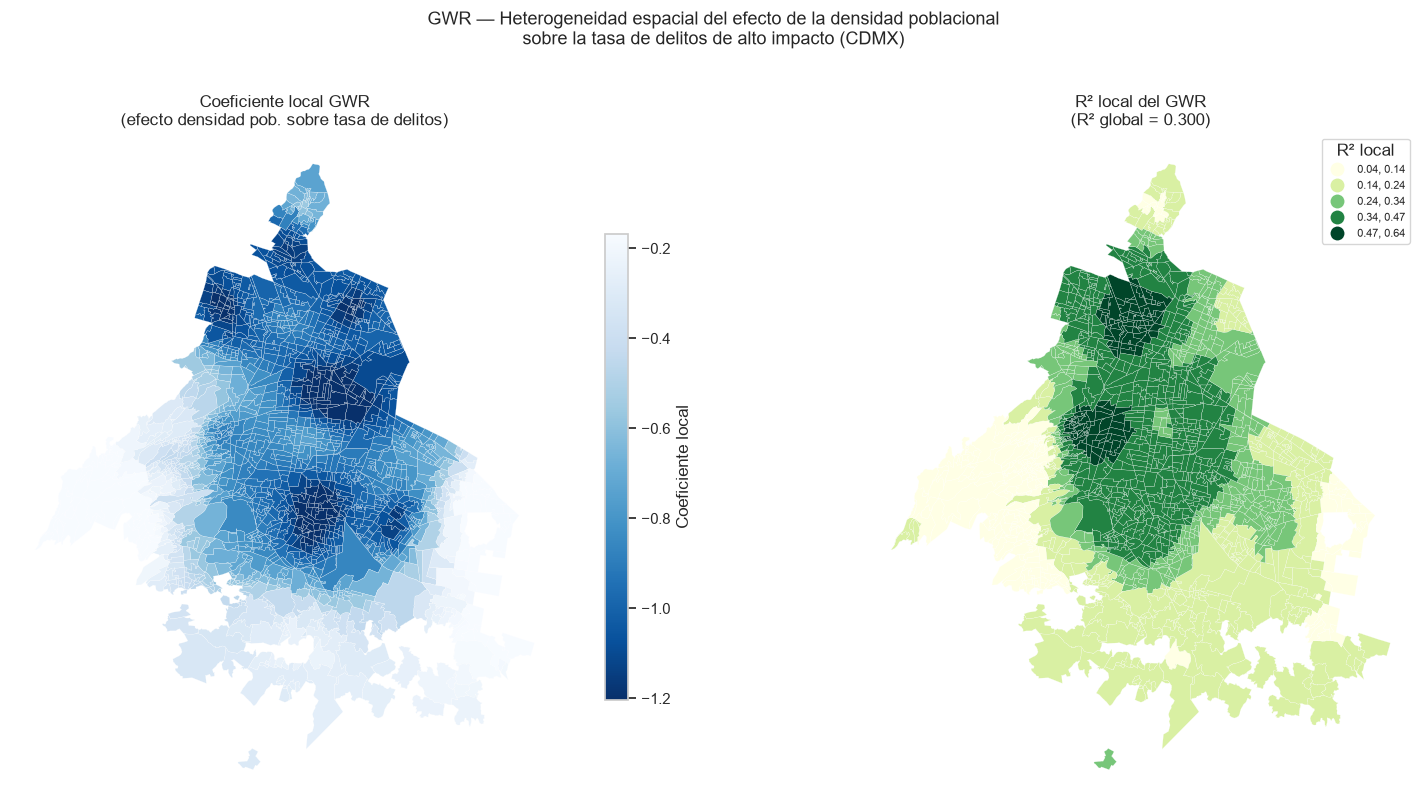

In [49]:
# Mapa de coeficientes locales (la figura central del GWR, como Fig.3 de Vilalta 2022)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Mapa 1: coeficiente local
vmin = gdf['gwr_coef_densidad'].quantile(0.05)
vmax = gdf['gwr_coef_densidad'].quantile(0.95)

# TwoSlopeNorm solo funciona si 0 está DENTRO del rango [vmin, vmax]
if vmin < 0 < vmax:
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = 'RdBu_r'
else:
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = 'Reds' if vmin >= 0 else 'Blues_r'

gdf.plot(
    column='gwr_coef_densidad',
    cmap=cmap, norm=norm,
    legend=True,
    ax=axes[0],
    edgecolor='white', linewidth=0.15,
    legend_kwds={'label': 'Coeficiente local', 'shrink': 0.7}
)
axes[0].set_title(
    'Coeficiente local GWR\n(efecto densidad pob. sobre tasa de delitos)',
    fontsize=12
)
axes[0].set_axis_off()

# Mapa 2: R² local
gdf.plot(
    column='gwr_r2_local',
    scheme='NaturalBreaks', k=5,
    cmap='YlGn',
    legend=True,
    ax=axes[1],
    edgecolor='white', linewidth=0.15,
    legend_kwds={'title': 'R² local', 'fontsize': 8}
)
axes[1].set_title(
    f'R² local del GWR\n(R² global = {gwr_results.R2:.3f})',
    fontsize=12
)
axes[1].set_axis_off()

plt.suptitle(
    'GWR — Heterogeneidad espacial del efecto de la densidad poblacional\nsobre la tasa de delitos de alto impacto (CDMX)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('resultados/06_gwr_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

Del grafico de la izqeuirda, si analizamos en la variable independiente su coeficiente local, podemos ver que en tres en la zonas, la norte, nor-este y centro, la densidad poblacional tiene un efecto negativo sobre la tasa de delitos.

Del grafico de la derecha  podemos ver que R^2 local es alto en el centro de la CDMX, pero bajo en la periferia, indicando que una sola variable no explica bien el fenómeno en zonas más alejadas.  
El R^2 global del modelo es 0.3. Esto indica que la variable independiente por si solo explica una parte limitada de la variacion en la tasa de delitos, por ello la necesidad de incorporar mas variables se justifica.

## 8. Guardar resultados finales

In [50]:
import os
os.makedirs('resultados', exist_ok=True)

# GeoDataFrame completo con todos los resultados
gdf.to_file('resultados/analisis_final.gpkg', driver='GPKG')
print('Guardado: resultados/analisis_final.gpkg')

# CSV sin geometría (para tablas del informe)
cols_csv = [c for c in gdf.columns if c != 'geometry']
gdf[cols_csv].to_csv('resultados/analisis_final.csv', index=False)
print('Guardado: resultados/analisis_final.csv')

print('\nArchivos generados para el informe:')
for f in sorted(os.listdir('resultados')):
    if f.endswith('.png'):
        print(f'  📊 {f}')

Guardado: resultados/analisis_final.gpkg
Guardado: resultados/analisis_final.csv

Archivos generados para el informe:
  📊 00_unidad_analisis.png
  📊 01_mapa_tasa_total.png
  📊 02_mapas_por_tipo.png
  📊 03_distribucion_temporal.png
  📊 04_moran_scatter.png
  📊 05_mapa_lisa.png
  📊 06_gwr_coeficientes.png
